# __Loan_prediction__

__Goal__ - We have to build a model that can predict whether the loan of the applicant will be approved or not on the basis of the details provided in the dataset.

## Import Libraries

In [1]:
## Data handling
import pandas as pd

## Numerical Computation
import numpy as np

## Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

## Machine Learning(scikit-learn)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler,PowerTransformer,LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score , confusion_matrix

## Scipy
from scipy.stats import zscore


## Load Dataset

In [2]:
df = pd.read_csv("loan_prediction.csv")
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


# __Exploratry Data Analysis(EDA):-__

## Understand The Data

In [3]:
print("(ROW,COLUMN)",df.shape)

(ROW,COLUMN) (614, 13)


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 62.5+ KB


#### Analysis from df.info():-

1.  Dependents is a int Value but it is Showing Object type,and we need to change object to int.

2.  There are some NaN value in this DataSet

__________________________________________

In [5]:
## Numerical Column Analysis
df.describe()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,614.000000,614.000000,592.000000,600.00000,564.000000
mean,5403.459283,1621.245798,146.412162,342.00000,0.842199
std,6109.041673,2926.248369,85.587325,65.12041,0.364878
min,150.000000,0.000000,9.000000,12.00000,0.000000
25%,2877.500000,0.000000,100.000000,360.00000,1.000000
50%,3812.500000,1188.500000,128.000000,360.00000,1.000000
75%,5795.000000,2297.250000,168.000000,360.00000,1.000000
max,81000.000000,41667.000000,700.000000,480.00000,1.000000


#### Analysis From df.describe():-

Dataset has missing values

CoapplicantIncome is right-skewed

Outliers present

________________________________

## Data Cleaning

#### Drop Unwanted Column

In [6]:
df.drop("Loan_ID",axis=1,inplace=True)

#### Handel Missing Value

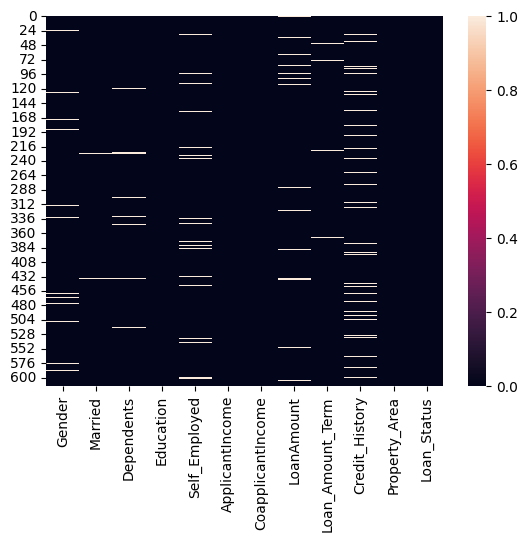

In [7]:
## Using heatmap(plot)
sns.heatmap(df.isnull())
plt.show()

In [8]:
nul_val = df.isnull().sum().sort_values(ascending=False)

In [9]:
nul_val_per = round(nul_val/len(df)*100)

In [10]:
print(pd.concat([nul_val,nul_val_per],axis=1,keys=['Null value','Nul value %']))

                   Null value  Nul value %
Credit_History             50          8.0
Self_Employed              32          5.0
LoanAmount                 22          4.0
Dependents                 15          2.0
Loan_Amount_Term           14          2.0
Gender                     13          2.0
Married                     3          0.0
Education                   0          0.0
CoapplicantIncome           0          0.0
ApplicantIncome             0          0.0
Property_Area               0          0.0
Loan_Status                 0          0.0


In [11]:
## Seprate the numerical values
for i in df.describe():
    print(i)

ApplicantIncome
CoapplicantIncome
LoanAmount
Loan_Amount_Term
Credit_History


In [12]:
num_null = ['Credit_History',"LoanAmount","Loan_Amount_Term"]

In [13]:
df[num_null] = df[num_null].fillna(df[num_null].median())

In [14]:
cat_null = [i for i in df.columns if df[i].dtype==object and df[i].isnull().sum()>0]

In [15]:
cat_null

['Gender', 'Married', 'Dependents', 'Self_Employed']

In [16]:
for i in cat_null:
    df[i].fillna(df[i].mode()[0],inplace=True)


In [17]:
print(f"There are {df.isnull().sum().sum()} NaN values in This Dataset")

There are 0 NaN values in This Dataset


#### Check Duplicate Values

In [18]:
dup=df.duplicated().sum()

print(f"There are {dup} duplicate values")

There are 0 duplicate values


#### Change Data Types

In [19]:
df['Dependents'].value_counts()

Dependents
0     360
1     102
2     101
3+     51
Name: count, dtype: int64

In [20]:
df['Dependents'] = df['Dependents'].replace("3+","3").astype(int)

## Outlier Treatment

In [21]:
for i in df.describe():
    print(i)

Dependents
ApplicantIncome
CoapplicantIncome
LoanAmount
Loan_Amount_Term
Credit_History


In [22]:
outlier = ['ApplicantIncome',"CoapplicantIncome","LoanAmount"]

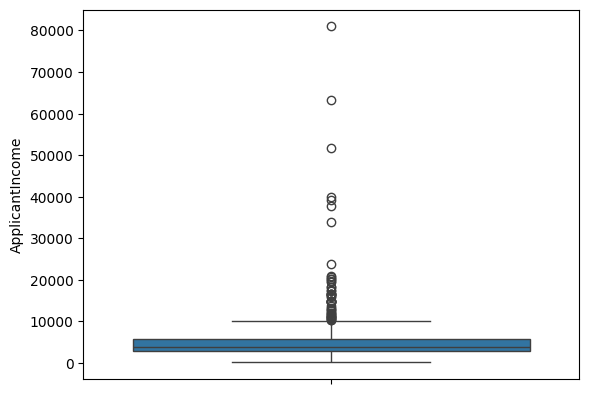

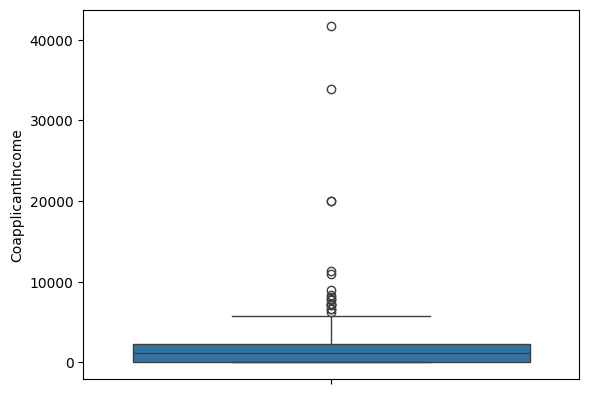

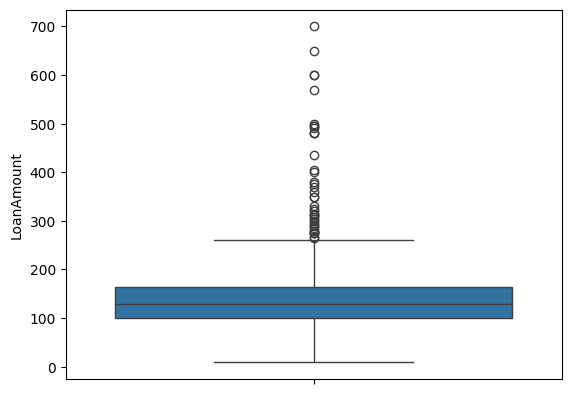

In [23]:
for i in outlier:
    sns.boxplot(df[i])
    plt.show()

In [24]:
# from scipy.stats import zscore

In [25]:
z = np.absolute(zscore(df[outlier]))

In [26]:
z

array([[0.07299082, 0.55448733, 0.21124125],
       [0.13441195, 0.03873155, 0.21124125],
       [0.39374734, 0.55448733, 0.94899647],
       ...,
       [0.43717437, 0.47240418, 1.27616847],
       [0.35706382, 0.55448733, 0.49081614],
       [0.13441195, 0.55448733, 0.15174486]], shape=(614, 3))

In [27]:
clean_data = df[(z<3).all(axis=1)] 

In [28]:
clean_data

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,Male,No,0,Graduate,No,5849,0.0,128.0,360.0,1.0,Urban,Y
1,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y
...,...,...,...,...,...,...,...,...,...,...,...,...
609,Female,No,0,Graduate,No,2900,0.0,71.0,360.0,1.0,Rural,Y
610,Male,Yes,3,Graduate,No,4106,0.0,40.0,180.0,1.0,Rural,Y
611,Male,Yes,1,Graduate,No,8072,240.0,253.0,360.0,1.0,Urban,Y
612,Male,Yes,2,Graduate,No,7583,0.0,187.0,360.0,1.0,Urban,Y


In [29]:
outlier_data = df[(z>3).any(axis=1)]

In [30]:
outlier_data.shape

(25, 12)

#### Percentage of data loss

In [31]:
data_loss = len(outlier_data)/len(df)*100

In [32]:
data_loss

4.071661237785016

#### Only 4% data loss.
_____________________________________________

## Univariate Analysis

#### Skewness Treatment

In [33]:
cols = ["ApplicantIncome","CoapplicantIncome","LoanAmount","Loan_Amount_Term"]
for col in cols:
    print(col)
    print("skew",clean_data[col].skew())
    print("*******************")

ApplicantIncome
skew 2.16476207904196
*******************
CoapplicantIncome
skew 1.3531905540940208
*******************
LoanAmount
skew 1.114173164102511
*******************
Loan_Amount_Term
skew -2.4460255069841494
*******************


#### Analysis from Skewness:-

1. ApplicantIncome (2.16) - This feature is positively skewed (right-skewed).

2. CoapplicantIncome (1.35)-This variable is also positively skewed.

3. LoanAmount (1.11)- This feature shows positive skewness.

4. Loan_Amount_Term (-2.44)- This variable is negatively skewed (left-skewed).

__________________________________________________________

C:\Users\vivek\AppData\Local\Temp\ipykernel_636\1126042399.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df[i])


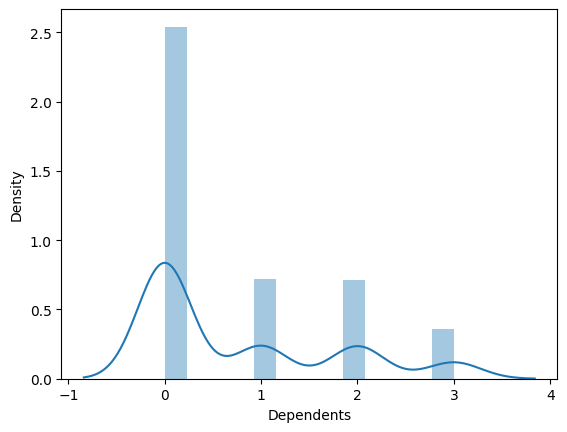

C:\Users\vivek\AppData\Local\Temp\ipykernel_636\1126042399.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df[i])


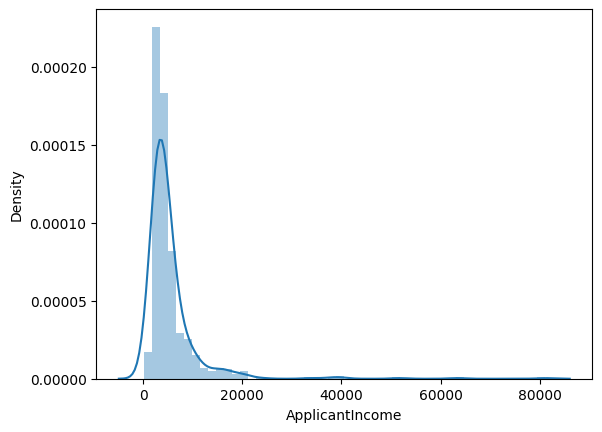

C:\Users\vivek\AppData\Local\Temp\ipykernel_636\1126042399.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df[i])


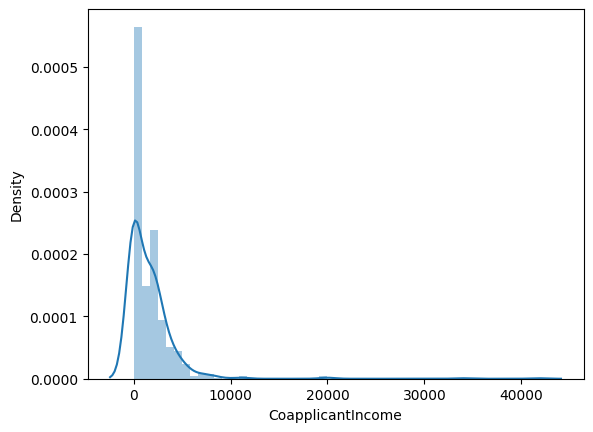

C:\Users\vivek\AppData\Local\Temp\ipykernel_636\1126042399.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df[i])


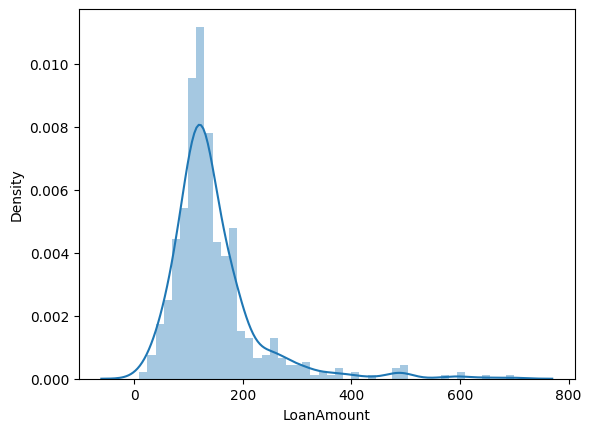

C:\Users\vivek\AppData\Local\Temp\ipykernel_636\1126042399.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df[i])


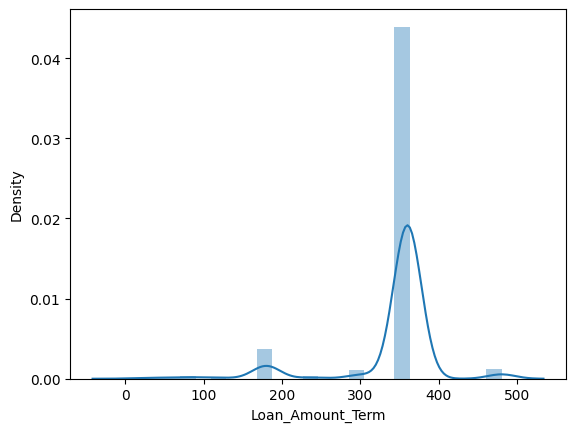

C:\Users\vivek\AppData\Local\Temp\ipykernel_636\1126042399.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df[i])


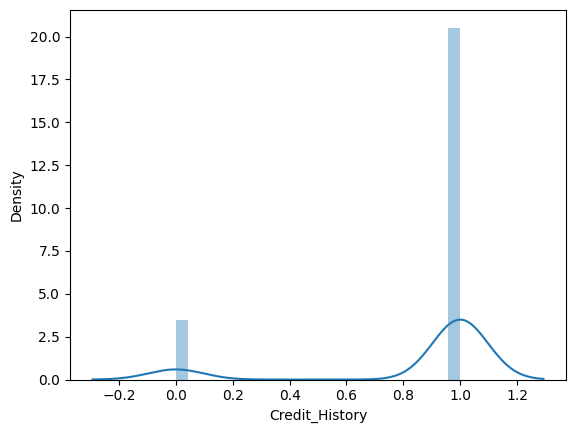

In [34]:
for i in df.describe():
    sns.distplot(df[i])
    plt.show()

In [35]:
# from sklearn.preprocessing import PowerTransformer

In [36]:
pt = PowerTransformer()

In [37]:
clean_data[cols] = pt.fit_transform(clean_data[cols]) 

C:\Users\vivek\AppData\Local\Temp\ipykernel_636\2252283825.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  clean_data[cols] = pt.fit_transform(clean_data[cols])


In [38]:
clean_data[cols].skew()

ApplicantIncome      0.028063
CoapplicantIncome   -0.186195
LoanAmount           0.061412
Loan_Amount_Term     0.399690
dtype: float64

In [39]:
clean_data.head()

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,Male,No,0,Graduate,No,0.688986,-1.119438,0.003682,0.175055,1.0,Urban,Y
1,Male,Yes,1,Graduate,No,0.239843,0.748807,0.003682,0.175055,1.0,Rural,N
2,Male,Yes,0,Graduate,Yes,-0.525799,-1.119438,-1.384802,0.175055,1.0,Urban,Y
3,Male,Yes,0,Not Graduate,No,-0.791841,0.899419,-0.148052,0.175055,1.0,Urban,Y
4,Male,No,0,Graduate,No,0.736280,-1.119438,0.238407,0.175055,1.0,Urban,Y


#### Almost normal Distribution
______________________________________________

## Encoding

In [40]:
# from sklearn.preprocessing import LabelEncoder

In [41]:
le = LabelEncoder()

#### Label Encoding

In [42]:
le.fit(clean_data['Property_Area'])

LabelEncoder()

In [43]:
clean_data['Property_Area'] = le.transform(clean_data['Property_Area'])

C:\Users\vivek\AppData\Local\Temp\ipykernel_636\2694471552.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  clean_data['Property_Area'] = le.transform(clean_data['Property_Area'])


In [44]:
le.fit(clean_data['Gender'])

LabelEncoder()

In [45]:
clean_data['Gender'] = le.transform(clean_data['Gender'])

C:\Users\vivek\AppData\Local\Temp\ipykernel_636\3744561995.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  clean_data['Gender'] = le.transform(clean_data['Gender'])


In [46]:
le.fit(clean_data['Married'])

LabelEncoder()

In [47]:
clean_data['Married'] = le.transform(clean_data['Married'])

C:\Users\vivek\AppData\Local\Temp\ipykernel_636\3308749689.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  clean_data['Married'] = le.transform(clean_data['Married'])


In [48]:
le.fit(clean_data['Education'])

LabelEncoder()

In [49]:
clean_data['Education'] = le.transform(clean_data['Education'])

C:\Users\vivek\AppData\Local\Temp\ipykernel_636\2132464028.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  clean_data['Education'] = le.transform(clean_data['Education'])


In [50]:
le.fit(clean_data['Self_Employed'])

LabelEncoder()

In [51]:
clean_data['Self_Employed'] = le.transform(clean_data['Self_Employed'])

C:\Users\vivek\AppData\Local\Temp\ipykernel_636\359153562.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  clean_data['Self_Employed'] = le.transform(clean_data['Self_Employed'])


In [52]:
clean_data.head()

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,1,0,0,0,0,0.688986,-1.119438,0.003682,0.175055,1.0,2,Y
1,1,1,1,0,0,0.239843,0.748807,0.003682,0.175055,1.0,0,N
2,1,1,0,0,1,-0.525799,-1.119438,-1.384802,0.175055,1.0,2,Y
3,1,1,0,1,0,-0.791841,0.899419,-0.148052,0.175055,1.0,2,Y
4,1,0,0,0,0,0.736280,-1.119438,0.238407,0.175055,1.0,2,Y


In [53]:
x = clean_data.iloc[:,:-1]
y = clean_data['Loan_Status']

## Train Test Split

In [54]:
# from sklearn.model_selection import train_test_split

In [55]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.3,random_state=42)

In [56]:
print("x_train Shape: ",x_train.shape)
print("y_train Shape: ",y_train.shape)
print("x_test Shape: ",x_test .shape)
print("y_test Shape: ",y_test.shape)

x_train Shape:  (412, 11)
y_train Shape:  (412,)
x_test Shape:  (177, 11)
y_test Shape:  (177,)


## Scalling

In [57]:
# from sklearn.preprocessing import MinMaxScaler

mm = MinMaxScaler()

In [58]:
x_train_scaled = mm.fit_transform(x_train)
x_test_scaled = mm.transform(x_test)

## Model Training

In [59]:
# from sklearn.linear_model import LogisticRegression

In [60]:
lr = LogisticRegression()

In [61]:
lr.fit(x_train,y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [62]:
pred_y = lr.predict(x_test)

In [63]:
df2 = [[1.0,0.0,0.000000,0.0,0.0,0.716341,0.000000,0.546815,0.417009,1.0,1.0]]

In [64]:
lr.predict(df2)

d:\PYTHON\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


array(['Y'], dtype=object)

## Check Accuracy

In [65]:
# from sklearn.metrics import accuracy_score,confusion_matrix

In [66]:
accuracy_score(y_test,pred_y)*100

80.22598870056498

## Confusion Metrics

In [67]:
con = confusion_matrix(y_test,pred_y)

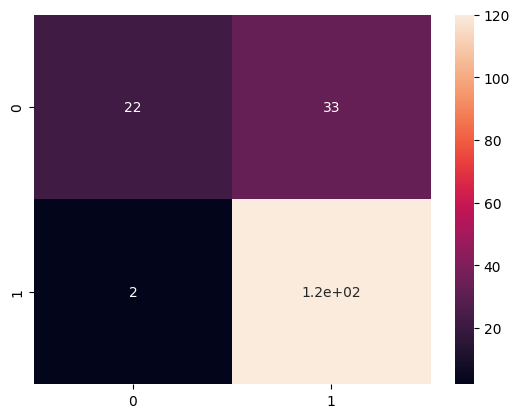

In [68]:
sns.heatmap(con,annot=True)
plt.show()